# Agentic RAG (Tool-Calling Agent)

This notebook builds the simplest of the three agentic RAG patterns in this repo: an
LLM **agent that decides for itself** whether it needs to look anything up before
answering, and which of two knowledge bases (LangGraph docs vs. LangChain docs) to
search.

**Flow:** `agent -> (tool call?) -> retrieve -> grade relevance -> generate or rewrite -> loop`

Compare this to `2_Corrective_RAG.ipynb` (always retrieves, then corrects with a web
search if the retrieval was bad) and `3_Adaptive_RAG.ipynb` (routes up front between a
vectorstore and the web, then self-checks the final answer for hallucinations).

Run the cells top to bottom. You'll need `GROQ_API_KEY` set — see the README for setup
with `uv`.


## 1. Imports
Everything we need: web scraping (`requests` + `BeautifulSoup`), the LangChain/LangGraph building blocks, Chroma as the vector store, and Groq as the LLM provider.

In [75]:
import os
from dotenv import load_dotenv
from IPython.display import Image, display
import requests
from bs4 import BeautifulSoup
from langchain_chroma import Chroma
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.tools import tool
from langchain_core.messages import (
    BaseMessage,
    AnyMessage,
    HumanMessage,
    AIMessage,
    SystemMessage
)
from langchain_core.output_parsers import StrOutputParser
from typing import Annotated, get_type_hints, List
from pydantic import BaseModel, Field
from langgraph.graph.message import add_messages
from typing import Literal
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_groq import ChatGroq
from langchain_core.prompts import ChatPromptTemplate


## 2. Load API keys
Keys are read from a local `.env` file (never commit this file — see `.env.example`).

In [6]:
load_dotenv()

GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY")
GROQ_API_KEY = os.getenv("GROQ_API_KEY")

## 3. Initialize the LLM
We use Groq's `openai/gpt-oss-120b` at `temperature=0` for deterministic, reproducible answers. Swap this for any other `langchain` chat model if you prefer.

In [107]:
groq_llm = ChatGroq(
    api_key=GROQ_API_KEY,
    model="openai/gpt-oss-120b",
    temperature=0
)

## 4. Pick source documentation
Two small sets of URLs: official LangGraph docs and official LangChain docs. These become two separate knowledge bases so the agent can later choose which one is relevant.

In [8]:
langgraph_urls = [
    "https://docs.langchain.com/oss/python/langgraph/overview",
    "https://docs.langchain.com/oss/python/langgraph/workflows-agents",  
    "https://docs.langchain.com/oss/python/langgraph/graph-api#map-reduce-and-the-send-api"  
]

langchain_urls = [
    "https://docs.langchain.com/oss/python/langchain/overview?utm_source=chatgpt.com",
    "https://docs.langchain.com/oss/python/langchain/models",
    "https://docs.langchain.com/oss/python/langchain/tools?utm_source=chatgpt.com"
]

## 5. Scrape the LangGraph docs
A plain `requests` + `BeautifulSoup` scrape — good enough for static docs pages. For JS-heavy sites you'd want a headless browser instead.

In [9]:
langgraph_docs = []

headers = {"User-Agent": "Mozilla/5.0"}

for url in langgraph_urls:
    response = requests.get(url, headers=headers)
    soup = BeautifulSoup(response.text, "html.parser")
    
    title = soup.title.string.strip() if soup.title else "No title"
    text = soup.get_text(separator="\n", strip=True)
    
    langgraph_docs.append({"source": url, "title": title, "text": text})

In [10]:
langgraph_docs

[{'source': 'https://docs.langchain.com/oss/python/langgraph/overview',
  'title': 'LangGraph overview - Docs by LangChain',
  'text': 'LangGraph overview - Docs by LangChain\nDocumentation Index\nFetch the complete documentation index at:\n/llms.txt\nUse this file to discover all available pages before exploring further.\nSkip to main content\nInterrupt is coming to NYC and London this fall. Join the builders, engineers, and teams shaping what\'s next for agents.\nGet your tickets →\nDocs by LangChain\nhome page\nBuild\nSearch...\n⌘\nK\nAsk AI\nGitHub\nTry LangSmith\nTry LangSmith\nSearch...\nNavigation\nLangGraph overview\nOverview\nDeep Agents\nManaged Deep Agents\nLangChain\nLangGraph\nOpenWiki\nIntegrations\nLearn\nReference\nContribute\nPython\nOverview\nGet started\nInstall\nQuickstart\nLocal server\nChangelog\nThinking in LangGraph\nWorkflows + agents\nCapabilities\nPersistence\nCheckpointers\nStores\nFault tolerance\nEvent streaming\nStreaming\nInterrupts\nTime travel\nMemory\

## 6. Scrape the LangChain docs
Same approach, second URL set.

In [11]:
langchain_docs = []

headers = {"User-Agent": "Mozilla/5.0"}

for url in langchain_urls:
    response = requests.get(url, headers=headers)
    soup = BeautifulSoup(response.text, "html.parser")
    
    title = soup.title.string.strip() if soup.title else "No title"
    text = soup.get_text(separator="\n", strip=True)
    
    langchain_docs.append({"source": url, "title": title, "text": text})

In [12]:
langchain_docs

[{'source': 'https://docs.langchain.com/oss/python/langchain/overview?utm_source=chatgpt.com',
  'title': 'LangChain overview - Docs by LangChain',
  'text': 'LangChain overview - Docs by LangChain\nDocumentation Index\nFetch the complete documentation index at:\n/llms.txt\nUse this file to discover all available pages before exploring further.\nSkip to main content\nInterrupt is coming to NYC and London this fall. Join the builders, engineers, and teams shaping what\'s next for agents.\nGet your tickets →\nDocs by LangChain\nhome page\nBuild\nSearch...\n⌘\nK\nAsk AI\nGitHub\nTry LangSmith\nTry LangSmith\nSearch...\nNavigation\nLangChain overview\nOverview\nDeep Agents\nManaged Deep Agents\nLangChain\nLangGraph\nOpenWiki\nIntegrations\nLearn\nReference\nContribute\nPython\nOverview\nGet started\nInstall\nQuickstart\nChangelog\nPhilosophy\nCore components\nAgents\nModels\nMessages\nTools\nShort-term memory\nEvent streaming\nStreaming\nStructured output\nMiddleware\nOverview\nPrebuilt mi

## 7. Wrap the LangGraph pages as LangChain `Document` objects
Each document keeps its source URL and title in `metadata`, which is what lets the retriever tool later cite where an answer came from.

In [13]:
langgraph_documents = []

for lgd in langgraph_docs:
    document = Document(
        page_content=lgd["text"],
        metadata={"source": lgd["source"], "title": lgd["title"]}
    )
    langgraph_documents.append(document)

In [14]:
langgraph_documents

[Document(metadata={'source': 'https://docs.langchain.com/oss/python/langgraph/overview', 'title': 'LangGraph overview - Docs by LangChain'}, page_content='LangGraph overview - Docs by LangChain\nDocumentation Index\nFetch the complete documentation index at:\n/llms.txt\nUse this file to discover all available pages before exploring further.\nSkip to main content\nInterrupt is coming to NYC and London this fall. Join the builders, engineers, and teams shaping what\'s next for agents.\nGet your tickets →\nDocs by LangChain\nhome page\nBuild\nSearch...\n⌘\nK\nAsk AI\nGitHub\nTry LangSmith\nTry LangSmith\nSearch...\nNavigation\nLangGraph overview\nOverview\nDeep Agents\nManaged Deep Agents\nLangChain\nLangGraph\nOpenWiki\nIntegrations\nLearn\nReference\nContribute\nPython\nOverview\nGet started\nInstall\nQuickstart\nLocal server\nChangelog\nThinking in LangGraph\nWorkflows + agents\nCapabilities\nPersistence\nCheckpointers\nStores\nFault tolerance\nEvent streaming\nStreaming\nInterrupts\n

## 8. Wrap the LangChain pages as `Document` objects
Same treatment for the second knowledge base.

In [15]:
langchain_documents = []

for lgd in langchain_docs:
    document = Document(
        page_content=lgd["text"],
        metadata={"source": lgd["source"], "title": lgd["title"]}
    )
    langchain_documents.append(document)

In [16]:
langchain_documents

[Document(metadata={'source': 'https://docs.langchain.com/oss/python/langchain/overview?utm_source=chatgpt.com', 'title': 'LangChain overview - Docs by LangChain'}, page_content='LangChain overview - Docs by LangChain\nDocumentation Index\nFetch the complete documentation index at:\n/llms.txt\nUse this file to discover all available pages before exploring further.\nSkip to main content\nInterrupt is coming to NYC and London this fall. Join the builders, engineers, and teams shaping what\'s next for agents.\nGet your tickets →\nDocs by LangChain\nhome page\nBuild\nSearch...\n⌘\nK\nAsk AI\nGitHub\nTry LangSmith\nTry LangSmith\nSearch...\nNavigation\nLangChain overview\nOverview\nDeep Agents\nManaged Deep Agents\nLangChain\nLangGraph\nOpenWiki\nIntegrations\nLearn\nReference\nContribute\nPython\nOverview\nGet started\nInstall\nQuickstart\nChangelog\nPhilosophy\nCore components\nAgents\nModels\nMessages\nTools\nShort-term memory\nEvent streaming\nStreaming\nStructured output\nMiddleware\nO

## 9. Chunk the documents
`RecursiveCharacterTextSplitter` breaks long pages into ~1000-character chunks with 200 characters of overlap, so retrieval returns focused passages instead of whole pages.

In [17]:
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200
)

In [18]:
langgraph_chunks = text_splitter.split_documents(langgraph_documents)

In [19]:
langgraph_chunks, len(langgraph_chunks)

([Document(metadata={'source': 'https://docs.langchain.com/oss/python/langgraph/overview', 'title': 'LangGraph overview - Docs by LangChain'}, page_content="LangGraph overview - Docs by LangChain\nDocumentation Index\nFetch the complete documentation index at:\n/llms.txt\nUse this file to discover all available pages before exploring further.\nSkip to main content\nInterrupt is coming to NYC and London this fall. Join the builders, engineers, and teams shaping what's next for agents.\nGet your tickets →\nDocs by LangChain\nhome page\nBuild\nSearch...\n⌘\nK\nAsk AI\nGitHub\nTry LangSmith\nTry LangSmith\nSearch...\nNavigation\nLangGraph overview\nOverview\nDeep Agents\nManaged Deep Agents\nLangChain\nLangGraph\nOpenWiki\nIntegrations\nLearn\nReference\nContribute\nPython\nOverview\nGet started\nInstall\nQuickstart\nLocal server\nChangelog\nThinking in LangGraph\nWorkflows + agents\nCapabilities\nPersistence\nCheckpointers\nStores\nFault tolerance\nEvent streaming\nStreaming\nInterrupts\n

In [20]:
langchain_chunks = text_splitter.split_documents(langchain_documents)

In [21]:
langchain_chunks, len(langchain_chunks)

([Document(metadata={'source': 'https://docs.langchain.com/oss/python/langchain/overview?utm_source=chatgpt.com', 'title': 'LangChain overview - Docs by LangChain'}, page_content="LangChain overview - Docs by LangChain\nDocumentation Index\nFetch the complete documentation index at:\n/llms.txt\nUse this file to discover all available pages before exploring further.\nSkip to main content\nInterrupt is coming to NYC and London this fall. Join the builders, engineers, and teams shaping what's next for agents.\nGet your tickets →\nDocs by LangChain\nhome page\nBuild\nSearch...\n⌘\nK\nAsk AI\nGitHub\nTry LangSmith\nTry LangSmith\nSearch...\nNavigation\nLangChain overview\nOverview\nDeep Agents\nManaged Deep Agents\nLangChain\nLangGraph\nOpenWiki\nIntegrations\nLearn\nReference\nContribute\nPython\nOverview\nGet started\nInstall\nQuickstart\nChangelog\nPhilosophy\nCore components\nAgents\nModels\nMessages\nTools\nShort-term memory\nEvent streaming\nStreaming\nStructured output\nMiddleware\nO

## 10. Create the embedding model
`BAAI/bge-m3` is a strong open-source multilingual embedding model that runs locally via `sentence-transformers` (no extra API key needed).

In [22]:
embedding_model = HuggingFaceEmbeddings(
    model_name="BAAI/bge-m3",
    show_progress=True,
    encode_kwargs={"batch_size": 32}
)

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

## 11. Build the two vector stores
Each knowledge base gets its own Chroma collection, so the agent can query them independently and even query only one if that's all the question needs.

In [23]:
langgraph_vectorstore = Chroma.from_documents(
    documents=langgraph_chunks,
    embedding=embedding_model,
    collection_name="langgraph_docs"
)


Batches:   0%|          | 0/4 [00:00<?, ?it/s]

In [24]:
langchain_vectorstore = Chroma.from_documents(
    documents=langchain_chunks,
    embedding=embedding_model,
    collection_name="langchain_docs"
)

Batches:   0%|          | 0/5 [00:00<?, ?it/s]

## 12. Sanity-check the LangGraph collection
Pull one stored record back out to confirm the embeddings, text, and metadata all landed correctly before building anything on top.

In [25]:
collection = langgraph_vectorstore._collection

print("Collection name:", collection.name)
print("Record count:", collection.count())

data = collection.get(
    limit=1,
    include=["embeddings", "documents", "metadatas"]
)

print("\n--- RECORD ---")

print("\nID:")
print(data["ids"][0])

print("\nDocument:")
print(data["documents"][0])

print("\nMetadata:")
print(data["metadatas"][0])

print("\nEmbedding:")
print(data["embeddings"][0])

Collection name: langgraph_docs
Record count: 110

--- RECORD ---

ID:
a775067b-52db-4bc8-98b2-03d6a366b025

Document:
LangGraph overview - Docs by LangChain
Documentation Index
Fetch the complete documentation index at:
/llms.txt
Use this file to discover all available pages before exploring further.
Skip to main content
Interrupt is coming to NYC and London this fall. Join the builders, engineers, and teams shaping what's next for agents.
Get your tickets →
Docs by LangChain
home page
Build
Search...
⌘
K
Ask AI
GitHub
Try LangSmith
Try LangSmith
Search...
Navigation
LangGraph overview
Overview
Deep Agents
Managed Deep Agents
LangChain
LangGraph
OpenWiki
Integrations
Learn
Reference
Contribute
Python
Overview
Get started
Install
Quickstart
Local server
Changelog
Thinking in LangGraph
Workflows + agents
Capabilities
Persistence
Checkpointers
Stores
Fault tolerance
Event streaming
Streaming
Interrupts
Time travel
Memory
Subgraphs
Production
Application structure
Test
Backward compatibil

## 13. Sanity-check the LangChain collection
Same check for the second collection.

In [26]:
collection = langchain_vectorstore._collection

print("Collection name:", collection.name)
print("Record count:", collection.count())

data = collection.get(
    limit=1,
    include=["embeddings", "documents", "metadatas"]
)

print("\n--- RECORD ---")

print("\nID:")
print(data["ids"][0])

print("\nDocument:")
print(data["documents"][0])

print("\nMetadata:")
print(data["metadatas"][0])

print("\nEmbedding:")
print(data["embeddings"][0])

Collection name: langchain_docs
Record count: 146

--- RECORD ---

ID:
95310596-f3ef-4cca-88fa-09d73eab136d

Document:
LangChain overview - Docs by LangChain
Documentation Index
Fetch the complete documentation index at:
/llms.txt
Use this file to discover all available pages before exploring further.
Skip to main content
Interrupt is coming to NYC and London this fall. Join the builders, engineers, and teams shaping what's next for agents.
Get your tickets →
Docs by LangChain
home page
Build
Search...
⌘
K
Ask AI
GitHub
Try LangSmith
Try LangSmith
Search...
Navigation
LangChain overview
Overview
Deep Agents
Managed Deep Agents
LangChain
LangGraph
OpenWiki
Integrations
Learn
Reference
Contribute
Python
Overview
Get started
Install
Quickstart
Changelog
Philosophy
Core components
Agents
Models
Messages
Tools
Short-term memory
Event streaming
Streaming
Structured output
Middleware
Overview
Prebuilt middleware
Custom middleware
Frontend
Overview
Patterns
Integrations
Advanced usage
Guardrai

## 14. Create retrievers
Similarity search, top-5 chunks per query, one retriever per knowledge base.

In [81]:
langgraph_retriever = langgraph_vectorstore.as_retriever(
    search_type="similarity",
    search_kwargs={"k": 5}
)

In [82]:
langchain_retriever = langchain_vectorstore.as_retriever(
    search_type="similarity",
    search_kwargs={"k": 5}
)

## 15. Turn each retriever into an agent tool
This is the key agentic step: instead of a fixed retrieval step, the LLM gets two callable **tools** with clear docstrings, and decides at runtime whether to call them at all, and which one fits the question.

In [108]:
@tool
def langgraph_retriever_tool(query: str) -> str:
    """Search and return information from the LangGraph documentation.
    Use this for questions about graphs, nodes, state, edges, checkpointing,
    or anything specific to LangGraph."""
    docs = langgraph_retriever.invoke(query)

    results = []
    for doc in docs:
        source = doc.metadata.get("source", "unknown")
        results.append(f"Source: {source}\n{doc.page_content}")

    if len(results) == 0:
        return "No relevant documents found."

    return "\n\n---\n\n".join(results)


@tool
def langchain_retriever_tool(query: str) -> str:
    """Search and return information from the LangChain documentation.
    Use this for questions about chains, prompts, models, LangChain agents,
    or anything specific to LangChain (not LangGraph)."""
    docs = langchain_retriever.invoke(query)

    results = []
    for doc in docs:
        source = doc.metadata.get("source", "unknown")
        results.append(f"Source: {source}\n{doc.page_content}")

    if len(results) == 0:
        return "No relevant documents found."

    return "\n\n---\n\n".join(results)

## 16. Quick manual retrieval test
Sanity-check that the LangGraph retriever returns something sensible before wiring it into the agent.

In [109]:
docs = langgraph_retriever.invoke("what is langgraph")

for i, doc in enumerate(docs, start=1):
    print("=" * 80)
    print(f"DOCUMENT {i}")
    print("=" * 80)

    print("Content:")
    print(doc.page_content)

    print("\nMetadata:")
    print(doc.metadata)

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

DOCUMENT 1
Content:
Time travel
Memory
Subgraphs
Production
Application structure
Test
Backward compatibility
LangSmith Studio
Agent Chat UI
Deployment
LangSmith Observability
Frontend
Overview
Graph execution
Custom stream channels
LangGraph APIs
Graph API
Functional API
Runtime
Studio
On this page
Install
Core benefits
LangGraph ecosystem
Acknowledgements
LangGraph overview
Copy page
Copy page
Gain control with LangGraph to design agents that reliably handle complex tasks
Copy page
Copy page
Trusted by companies shaping the future of agents—including Klarna, Uber, J.P. Morgan, and more—LangGraph is a low-level orchestration framework and runtime for building, managing, and deploying long-running, stateful agents. LangGraph gives you fine-grained control to mix deterministic, hand-coded steps with LLM-driven agentic steps in the same graph, so you can build bespoke agents that behave exactly the way your application requires.
LangGraph is very low-level, and focused entirely on agent


## 17. Bind the tools to the LLM + add a relevance grader
`bind_tools` gives the LLM the ability to call either retriever. `llm_grading` is a second, structured-output call used later to score whether retrieved documents actually answer the question.

In [110]:
tools = [langgraph_retriever_tool, langchain_retriever_tool]

llm_with_tools = groq_llm.bind_tools(tools)

In [111]:
class grade(BaseModel):
    """Binary score for relevance check."""

    binary_score: str = Field(description="Relevance score 'yes' or 'no'")
    
llm_grading = groq_llm.with_structured_output(grade)

## 18. Define the graph state
A single `messages` list (the standard LangGraph chat pattern) that accumulates the conversation, tool calls, and tool results.

In [112]:
class State(BaseModel):
    messages: Annotated[List[BaseMessage], add_messages] = []

## 19. Define the graph nodes
- `agent` — calls the LLM, which may respond directly or request a tool
- `grade_documents` — scores whether the tool's retrieved docs are relevant
- `generate` — writes the final answer from relevant docs
- `rewrite` — improves the question and sends it back to the agent if the docs weren't relevant
- `router` — decides whether the agent's last message needs a tool call or is already the final answer

In [113]:
def agent(state: State):
    """
    Invoke the agent model to generate a response based n the current state. Given the 
    question, it will decide to retrieve using the retriever tool, or simply end.
    
    Args: 
        current state messages
    
    Return:
        dict: updated state with agent response appended to the state
    
    """
    print("---CALL AGENT---")
    messages = state.messages
    response = llm_with_tools.invoke(messages)
    
    return {
        "messages": [response]
    }
    
    
def grade_documents(state: State) -> Literal["generate", "rewrite"]:
    """
    Determines whether the retrieved documents are relevant to the question.

    Args:
        state (messages): The current state

    Returns:
        str: A decision for whether the documents are relevant or not
    """
    
    print("---CHECK RELEVANCE---")
    
    prompt = ChatPromptTemplate.from_template(
        """Decide whether the retrieved passage below is actually useful for answering the question. \n 
        Retrieved passage: \n\n {context} \n\n
        Question: {question} \n
        Count it as relevant if it overlaps with the question either in specific keywords or in overall meaning. \n
        Reply with only 'yes' or 'no'.
        """
    )
    
    chain = prompt | llm_grading
    
    messages = state.messages
    last_message = messages[-1]
    
    question = messages[0].content
    docs = last_message.content
    
    scored_result = chain.invoke({"question": question, "context": docs})
    
    score = scored_result.binary_score
    
    if score == "yes":
        print("---DECISION: DOCS RELEVANT---")
        return "generate"

    else:
        print("---DECISION: DOCS NOT RELEVANT---")
        print(score)
        return "rewrite"
    

def generate(state: State):
    """
    Generate answer

    Args:
        state (messages): The current state

    Returns:
         dict: The updated message
    """
    print("---GENERATE---")
    messages = state.messages
    question = messages[0].content
    last_message = messages[-1]

    docs = last_message.content

    prompt = ChatPromptTemplate.from_template(
    """ 
    Answer the question using only the context provided below.
    If the context doesn't give you enough to answer, say you don't know instead of guessing.
    Keep the answer to three sentences or fewer.

    Question: {question}
    Context: {context}
    Answer:
    """
    )

    rag_chain = prompt | groq_llm | StrOutputParser()

    # Run
    response = rag_chain.invoke({"context": docs, "question": question})
    return {
        "messages": AIMessage(content=response)
    }


def rewrite(state):
    """
    Transform the query to produce a better question.

    Args:
        state (messages): The current state

    Returns:
        dict: The updated state with re-phrased question
    """

    print("---TRANSFORM QUERY---")
    messages = state.messages
    question = messages[0].content

    prompt = ChatPromptTemplate.from_template(
        """ \n 
    Rewrite the question below so it retrieves better matches, focusing on the intent behind it rather than the exact original wording. \n 
    Original question:
    \n ------- \n
    {question} 
    \n ------- \n
    Improved question: """
    )

    rewrite_chain = prompt | groq_llm

    response = rewrite_chain.invoke({"question": question})

    return {
        "messages": [response]
    }
    
def router(state: State):
    
    last_message = state.messages[-1]
    
    if last_message.tool_calls:
        return "use_tool"
    else:
        return "finish"

## 20. Assemble the graph
Wire the nodes together: the agent can loop through a retrieval → grade → rewrite → agent cycle until it either has good documents to answer from, or decides no tool is needed.

In [114]:
workflow = StateGraph(State)

workflow.add_node("Agent", agent)
workflow.add_node("Retriver", ToolNode(tools))
workflow.add_node("Rewrite", rewrite)
workflow.add_node("Generate", generate)

workflow.add_edge(START, "Agent")
workflow.add_conditional_edges("Agent", router, {"use_tool": "Retriver", "finish": END})
workflow.add_conditional_edges("Retriver", grade_documents, {"generate": "Generate", "rewrite": "Rewrite"})
workflow.add_edge("Generate", END)
workflow.add_edge("Rewrite", "Agent")

## 21. Compile and visualize
Rendering the graph as a diagram is the fastest way to sanity-check the wiring before running real queries.

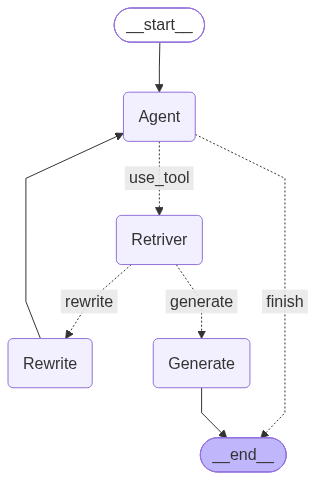

In [115]:
workflow_builder = workflow.compile()

display(Image(workflow_builder.get_graph().draw_mermaid_png()))

## 22. Try it
Ask a question that should trigger a tool call into one of the two knowledge bases.

In [126]:
input_message = [HumanMessage(content="What are langchain modules in docs")]

In [127]:
workflow_builder.invoke({"messages": input_message})

---CALL AGENT---


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

---CHECK RELEVANCE---
---DECISION: DOCS RELEVANT---
---GENERATE---


{'messages': [HumanMessage(content='What are langchain modules in docs', additional_kwargs={}, response_metadata={}, id='69f0f188-8207-4671-936b-28183968865b'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'The user asks: "What are langchain modules in docs". Likely they want explanation of modules in LangChain documentation. Could retrieve from LangChain docs. Use function.', 'tool_calls': [{'id': 'fc_b9fd5aab-63d6-4e06-ab87-4c1e2ba3ea06', 'function': {'arguments': '{"query":"LangChain modules documentation"}', 'name': 'langchain_retriever_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 70, 'prompt_tokens': 216, 'total_tokens': 286, 'completion_time': 0.147085469, 'completion_tokens_details': {'reasoning_tokens': 36}, 'prompt_time': 0.010074178, 'prompt_tokens_details': None, 'queue_time': 0.375321688, 'total_time': 0.157159647}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_017482bd7f', 'service_tier': 'on_dem